# TP2 — Segmentation RFM : Lumina & Co

## Objectif

Identifier les principaux profils clients à partir de leur récence, de leur fréquence d’achat et du montant total dépensé, puis proposer des actions marketing adaptées à chaque segment.

### Définition des indicateurs

- **Récence (R)** : nombre de jours entre le dernier achat du client et la date maximale du dataset.
- **Fréquence (F)** : nombre de factures distinctes du client.
- **Montant (M)** : somme totale dépensée par le client.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

sns.set_theme(style="whitegrid")

print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


In [2]:
transactions = pd.read_csv(
    "transactions.csv",
    parse_dates=["invoice_date"]
)

print(f"Nombre de lignes : {len(transactions):,}")
print(f"Nombre de colonnes : {transactions.shape[1]}")

display(transactions.head())

Nombre de lignes : 1,613,433
Nombre de colonnes : 9


,invoice_id,customer_id,product_code,product_name,category,quantity,unit_price,invoice_date,country
0,509453,"13,381.00",82583,Savon Surgras Lavande,Corps,3,7.72,2024-12-12 20:59:00,France
1,558926,"17,469.00",23201,Lait Corps Amande Douce,Corps,1,18.21,2026-01-23 21:31:00,France
2,567853,"15,484.00",23289,Savon Surgras Lavande,Corps,1,7.53,2026-04-13 00:41:00,France
3,549949,"13,208.00",22289,Huile Démaquillante Camélia,Visage,1,22.84,2025-11-02 00:07:00,France
4,505081,"16,742.00",22607,Coffret Découverte Rituel Slow Beauty,Coffret,1,47.12,2024-11-08 20:59:00,France


In [3]:
print("Types des colonnes :")
print(transactions.dtypes)

print("\nValeurs manquantes :")
display(
    transactions.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("valeurs_manquantes")
)

print(f"\nDoublons exacts : {transactions.duplicated().sum():,}")
print(f"Date minimale : {transactions['invoice_date'].min()}")
print(f"Date maximale : {transactions['invoice_date'].max()}")

Types des colonnes :
invoice_id                 str
customer_id            float64
product_code               str
product_name               str
category                   str
quantity                 int64
unit_price             float64
invoice_date    datetime64[us]
country                    str
dtype: object

Valeurs manquantes :


,valeurs_manquantes
customer_id,367328
product_name,2241
invoice_id,0
product_code,0
category,0
quantity,0
unit_price,0
invoice_date,0
country,0



Doublons exacts : 445
Date minimale : 2022-01-07 00:00:00
Date maximale : 2026-06-30 00:00:00


In [4]:
controle_numerique = pd.DataFrame({
    "minimum": transactions[["quantity", "unit_price"]].min(),
    "maximum": transactions[["quantity", "unit_price"]].max(),
    "valeurs_nulles": (transactions[["quantity", "unit_price"]] == 0).sum(),
    "valeurs_negatives": (transactions[["quantity", "unit_price"]] < 0).sum()
})

display(controle_numerique)

,minimum,maximum,valeurs_nulles,valeurs_negatives
quantity,-5.00,5.00,0,34691
unit_price,-8.40,57.75,10897,177


In [5]:
print("Exemples avec une quantité négative :")
display(
    transactions.loc[transactions["quantity"] < 0].head(10)
)

print("\nExemples avec un prix nul :")
display(
    transactions.loc[transactions["unit_price"] == 0].head(10)
)

print("\nExemples avec un prix négatif :")
display(
    transactions.loc[transactions["unit_price"] < 0].head(10)
)

Exemples avec une quantité négative :


,invoice_id,customer_id,product_code,product_name,category,quantity,unit_price,invoice_date,country
10,C506602,NaN,S,Échantillon,Frais,-1,0.00,2024-11-19 02:06:00,France
102,C510213,"16,485.00",79323GR,Frais divers,Frais,-1,2.62,2024-12-16 19:25:00,France
139,733050,"50,302.00",47566,Contour des Yeux Concombre,Visage,-3,26.18,2026-03-06 00:00:00,France
154,C518342,"16,168.00",22567,Eau Micellaire Fleur d'Oranger,Visage,-2,15.46,2025-02-25 01:03:00,France
181,683383,"36,615.00",79066K,Coffret Duo Visage Bio,Coffret,-2,56.84,2025-08-25 00:00:00,France
219,C536080,"13,626.00",22825,Gommage Corps Sucre Coco,Corps,-3,21.22,2025-06-20 22:21:00,France
259,712427,"43,673.00",21977,Coffret Découverte Rituel Slow Beauty,Coffret,-3,50.26,2025-09-30 00:00:00,France
296,676326,"34,694.00",90057,Lait Corps Amande Douce,Corps,-1,18.76,2024-12-06 00:00:00,France
311,C557387,NaN,M,Ajustement manuel,Frais,-1,0.00,2026-01-08 22:12:00,EIRE
315,744610,"54,088.00",84997A,Eau Micellaire Fleur d'Oranger,Visage,-1,15.41,2024-04-21 00:00:00,France



Exemples avec un prix nul :


,invoice_id,customer_id,product_code,product_name,category,quantity,unit_price,invoice_date,country
10,C506602,NaN,S,Échantillon,Frais,-1,0.00,2024-11-19 02:06:00,France
209,584543,"18,524.00",21412,Sel de Bain Fleur de Sel Provence,Bain,1,0.00,2025-01-01 00:00:00,France
311,C557387,NaN,M,Ajustement manuel,Frais,-1,0.00,2026-01-08 22:12:00,EIRE
455,750173,NaN,21090,Masque Argile Verte Purifiant,Visage,1,0.00,2025-11-28 00:00:00,France
621,511453,NaN,84795D,Eau Micellaire Fleur d'Oranger,Visage,4,0.00,2024-12-27 23:55:00,France
646,602796,"19,962.00",85123A,Sérum Visage Bio Rose Musquée,Visage,3,0.00,2025-05-29 00:00:00,France
700,680302,"35,066.00",23211,Brosse Corps Fibres Naturelles,Accessoire,2,0.00,2025-11-05 00:00:00,France
703,564920,NaN,48116,Huile Capillaire Ricin Bio,Cheveux,1,0.00,2026-03-21 23:53:00,France
735,527689,NaN,22596,Contour des Yeux Concombre,Visage,-1,0.00,2025-05-09 02:07:00,France
749,517814,NaN,22511,Lait Corps Amande Douce,Corps,1,0.00,2025-02-20 22:54:00,France



Exemples avec un prix négatif :


,invoice_id,customer_id,product_code,product_name,category,quantity,unit_price,invoice_date,country
3238,C491428,"15,494.00",D,Remise commerciale,Frais,-1,-8.36,2024-07-01 07:33:00,France
3398,C562796,"13,694.00",D,Remise commerciale,Frais,-1,-7.73,2026-02-28 01:37:00,France
29636,C565313,"14,527.00",D,Remise commerciale,Frais,-1,-8.21,2026-03-23 23:51:00,France
50032,C530507,"14,912.00",D,Remise commerciale,Frais,-1,-7.80,2025-05-24 23:00:00,Italy
54220,C519807,"16,422.00",D,Remise commerciale,Frais,-1,-8.10,2025-03-10 23:58:00,France
67283,C523987,"12,931.00",D,Remise commerciale,Frais,-1,-8.02,2025-04-17 01:22:00,France
71129,C564812,"14,527.00",D,Remise commerciale,Frais,-1,-8.37,2026-03-20 22:55:00,France
75580,C510832,"17,581.00",D,Remise commerciale,Frais,-1,-8.01,2024-12-23 07:24:00,France
78512,C539003,"14,527.00",D,Remise commerciale,Frais,-1,-8.30,2025-07-05 23:45:00,France
86082,C518758,"14,911.00",D,Remise commerciale,Frais,-1,-7.98,2025-03-02 00:34:00,EIRE


In [6]:
transactions_clean = (
    transactions
    .dropna(subset=["customer_id"])
    .drop_duplicates()
    .copy()
)

transactions_clean["customer_id"] = transactions_clean["customer_id"].astype("int64")

# Montant normal : positif pour un achat, négatif pour un retour
transactions_clean["line_total"] = (
    transactions_clean["quantity"] * transactions_clean["unit_price"]
)

# Une remise doit toujours diminuer le montant de la facture
masque_remise = transactions_clean["unit_price"] < 0
transactions_clean.loc[masque_remise, "line_total"] = -transactions_clean.loc[
    masque_remise, ["quantity", "unit_price"]
].prod(axis=1).abs()

print(f"Lignes avant nettoyage : {len(transactions):,}")
print(f"Lignes après nettoyage : {len(transactions_clean):,}")
print(f"Clients conservés : {transactions_clean['customer_id'].nunique():,}")
print(f"Montant total net : {transactions_clean['line_total'].sum():,.2f} €")

display(transactions_clean.head())

Lignes avant nettoyage : 1,613,433
Lignes après nettoyage : 1,245,850
Clients conservés : 49,402
Montant total net : 39,115,669.76 €


,invoice_id,customer_id,product_code,product_name,category,quantity,unit_price,invoice_date,country,line_total
0,509453,13381,82583,Savon Surgras Lavande,Corps,3,7.72,2024-12-12 20:59:00,France,23.16
1,558926,17469,23201,Lait Corps Amande Douce,Corps,1,18.21,2026-01-23 21:31:00,France,18.21
2,567853,15484,23289,Savon Surgras Lavande,Corps,1,7.53,2026-04-13 00:41:00,France,7.53
3,549949,13208,22289,Huile Démaquillante Camélia,Visage,1,22.84,2025-11-02 00:07:00,France,22.84
4,505081,16742,22607,Coffret Découverte Rituel Slow Beauty,Coffret,1,47.12,2024-11-08 20:59:00,France,47.12


In [8]:
factures = (
    transactions_clean
    .groupby(
        ["customer_id", "invoice_id"],
        as_index=False
    )
    .agg(
        invoice_date=("invoice_date", "max"),
        invoice_total=("line_total", "sum")
    )
)

print(f"Nombre total de factures distinctes : {len(factures):,}")
print(f"Factures positives : {(factures['invoice_total'] > 0).sum():,}")
print(f"Factures négatives : {(factures['invoice_total'] < 0).sum():,}")
print(f"Factures à 0 € : {(factures['invoice_total'] == 0).sum():,}")

display(factures.head())

Nombre total de factures distinctes : 225,141
Factures positives : 213,717
Factures négatives : 10,602
Factures à 0 € : 822


,customer_id,invoice_id,invoice_date,invoice_total
0,12346,491725,2024-07-04 19:44:00,2.46
1,12346,491742,2024-07-04 22:10:00,2.54
2,12346,491744,2024-07-04 22:12:00,2.44
3,12346,492718,2024-07-08 21:57:00,2.54
4,12346,492722,2024-07-08 22:05:00,2.47


In [9]:
snapshot_date = transactions_clean["invoice_date"].max()
achats = factures.loc[factures["invoice_total"] > 0].copy()

recence_frequence = (
    achats
    .groupby("customer_id")
    .agg(
        dernier_achat=("invoice_date", "max"),
        premier_achat=("invoice_date", "min"),
        frequence=("invoice_id", "nunique")
    )
)

montants = (
    factures
    .groupby("customer_id")
    .agg(montant=("invoice_total", "sum"))
)

rfm = recence_frequence.join(montants).reset_index()

rfm["recence"] = (
    snapshot_date.normalize() - rfm["dernier_achat"].dt.normalize()
).dt.days

rfm["anciennete"] = (
    snapshot_date.normalize() - rfm["premier_achat"].dt.normalize()
).dt.days

rfm["panier_moyen"] = rfm["montant"] / rfm["frequence"]

rfm = rfm[
    [
        "customer_id",
        "recence",
        "frequence",
        "montant",
        "panier_moyen",
        "anciennete"
    ]
]

print(f"Date de référence : {snapshot_date}")
print(f"Nombre de clients RFM : {len(rfm):,}")

display(rfm.head())
display(rfm[["recence", "frequence", "montant"]].describe())

Date de référence : 2026-06-30 00:00:00
Nombre de clients RFM : 49,061


,customer_id,recence,frequence,montant,panier_moyen,anciennete
0,12346,326,12,685.94,57.16,726
1,12347,2,8,"7,740.74",967.59,404
2,12348,75,5,"1,561.92",312.38,438
3,12349,19,4,"5,342.41","1,335.60",589
4,12350,310,1,554.75,554.75,310


,recence,frequence,montant
count,"49,061.00","49,061.00","49,061.00"
mean,312.43,4.36,797.51
std,295.24,5.76,"4,083.49"
min,0.00,1.00,-888.09
25%,72.00,1.00,99.26
50%,208.00,3.00,238.59
75%,490.00,6.00,559.43
max,"1,635.00",379.00,"409,497.79"


In [10]:
# Percentiles avec la même note pour les valeurs identiques
rang_r = rfm["recence"].rank(method="average", pct=True)
rang_f = rfm["frequence"].rank(method="average", pct=True)
rang_m = rfm["montant"].rank(method="average", pct=True)

# Plus la récence est faible, meilleur est le score
rfm["R"] = (6 - np.ceil(rang_r * 5)).clip(1, 5).astype(int)

# Plus la fréquence et le montant sont élevés, meilleur est le score
rfm["F"] = np.ceil(rang_f * 5).clip(1, 5).astype(int)
rfm["M"] = np.ceil(rang_m * 5).clip(1, 5).astype(int)

rfm["score_rfm"] = (
    rfm["R"].astype(str)
    + rfm["F"].astype(str)
    + rfm["M"].astype(str)
)

print("Distribution du score R :")
print(rfm["R"].value_counts().sort_index())

print("\nDistribution du score F :")
print(rfm["F"].value_counts().sort_index())

print("\nDistribution du score M :")
print(rfm["M"].value_counts().sort_index())

display(rfm.head())

Distribution du score R :
R
1    9816
2    9826
3    9774
4    9803
5    9842
Name: count, dtype: int64

Distribution du score F :
F
1    14613
2     8600
3     6205
4     9435
5    10208
Name: count, dtype: int64

Distribution du score M :
M
1    9811
2    9811
3    9815
4    9811
5    9813
Name: count, dtype: int64


,customer_id,recence,frequence,montant,panier_moyen,anciennete,R,F,M,score_rfm
0,12346,326,12,685.94,57.16,726,2,5,5,255
1,12347,2,8,"7,740.74",967.59,404,5,5,5,555
2,12348,75,5,"1,561.92",312.38,438,4,4,5,445
3,12349,19,4,"5,342.41","1,335.60",589,5,4,5,545
4,12350,310,1,554.75,554.75,310,2,1,4,214


In [11]:
conditions = [
    # Clients récents, fréquents et à forte valeur
    (rfm["R"] >= 4) & (rfm["F"] >= 4) & (rfm["M"] >= 4),

    # Clients réguliers et rentables
    (rfm["R"] >= 3) & (rfm["F"] >= 4) & (rfm["M"] >= 3),

    # Bons clients historiques devenus peu récents
    (rfm["R"] <= 2) & (rfm["F"] >= 3) & (rfm["M"] >= 3),

    # Clients très récents avec encore peu de commandes
    (rfm["R"] >= 4) & (rfm["F"] <= 2),

    # Clients récents ayant un potentiel de fidélisation
    (rfm["R"] >= 3) & (rfm["F"].between(2, 3)) & (rfm["M"] >= 2),

    # Clients très anciens, peu fréquents et à faible valeur
    (rfm["R"] == 1) & (rfm["F"] <= 2) & (rfm["M"] <= 2),

    # Clients anciens ne correspondant pas aux profils précédents
    (rfm["R"] <= 2)
]

segments = [
    "Champions",
    "Fidèles",
    "À risque",
    "Nouveaux prometteurs",
    "Potentiels fidèles",
    "Perdus",
    "Hibernants"
]

rfm["segment"] = np.select(
    conditions,
    segments,
    default="Clients moyens"
)

distribution_segments = (
    rfm["segment"]
    .value_counts()
    .rename_axis("segment")
    .reset_index(name="nombre_clients")
)

distribution_segments["proportion_pct"] = (
    distribution_segments["nombre_clients"] / len(rfm) * 100
).round(2)

display(distribution_segments)

,segment,nombre_clients,proportion_pct
0,Champions,10094,20.57
1,Hibernants,8171,16.65
2,Perdus,6758,13.77
3,Fidèles,5932,12.09
4,Nouveaux prometteurs,5748,11.72
5,Potentiels fidèles,5075,10.34
6,À risque,4713,9.61
7,Clients moyens,2570,5.24


In [12]:
ca_total = rfm["montant"].sum()

champions = rfm[rfm["segment"] == "Champions"]
champions_555 = rfm[rfm["score_rfm"] == "555"]
clients_risque = rfm[rfm["segment"] == "À risque"]
clients_111 = rfm[rfm["score_rfm"] == "111"]

part_ca_champions = champions["montant"].sum() / ca_total * 100
proportion_111 = len(clients_111) / len(rfm) * 100

print("CHAMPIONS")
print(f"Champions selon nos règles : {len(champions):,}")
print(f"Clients ayant exactement le score 555 : {len(champions_555):,}")
print(f"Part du CA réalisée par les Champions : {part_ca_champions:.2f} %")

print("\nCLIENTS À RISQUE")
print(f"Nombre de clients à risque : {len(clients_risque):,}")

print("\nCLIENTS PERDUS — SCORE EXACT 111")
print(f"Nombre de clients 111 : {len(clients_111):,}")
print(f"Proportion de la base : {proportion_111:.2f} %")

CHAMPIONS
Champions selon nos règles : 10,094
Clients ayant exactement le score 555 : 3,073
Part du CA réalisée par les Champions : 64.29 %

CLIENTS À RISQUE
Nombre de clients à risque : 4,713

CLIENTS PERDUS — SCORE EXACT 111
Nombre de clients 111 : 3,643
Proportion de la base : 7.43 %


In [14]:
## Analyse des principaux segments

### Champions

Selon les règles retenues, la base contient **10 094 Champions**, soit **20,57 % des clients**. Parmi eux, **3 073 clients possèdent exactement le score 555**.

Les Champions représentent **64,29 % du chiffre d’affaires net**. Leur poids économique est donc beaucoup plus important que leur poids dans la clientèle. Ces clients achètent récemment, régulièrement et dépensent des montants élevés.

L’entreprise doit chercher à les fidéliser avec un programme VIP, des avantages exclusifs, un accès anticipé aux nouveautés et des recommandations personnalisées. Il faut éviter les réductions systématiques, car ces clients achètent déjà fréquemment.

### Clients à risque

La base contient **4 713 clients à risque**, soit **9,61 % des clients**. Ils possèdent une valeur historique élevée, mais leur dernier achat est ancien.

Une campagne de réactivation personnalisée est recommandée : rappel des produits précédemment achetés, offre limitée dans le temps ou avantage fidélité. Ce segment doit être traité rapidement, car l’entreprise risque de perdre des clients ayant déjà démontré une forte valeur.

### Clients perdus

**3 643 clients possèdent exactement le score 111**, soit **7,43 % de la base**. Ils n’ont pas acheté récemment, ont réalisé peu de commandes et ont généré un faible montant.

Une campagne de réactivation peu coûteuse peut être testée, par exemple un email automatisé avec une offre unique. En l’absence de réaction, ces clients doivent être exclus des campagnes publicitaires coûteuses afin de concentrer le budget sur des segments ayant un meilleur potentiel.

### Amélioration de la segmentation

Les trois profils extrêmes ne suffisent pas à représenter toute la clientèle. La segmentation a donc été complétée par cinq profils supplémentaires : **Fidèles, Nouveaux prometteurs, Potentiels fidèles, Hibernants et Clients moyens**. Cette approche permet d’attribuer une stratégie marketing à chaque client selon sa valeur actuelle, son risque d’inactivité et son potentiel de croissance.

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (3258412335.py, line 5)

## Analyse des principaux segments

### Champions

Selon les règles retenues, la base contient **10 094 Champions**, soit **20,57 % des clients**. Parmi eux, **3 073 clients possèdent exactement le score 555**.

Les Champions représentent **64,29 % du chiffre d’affaires net**. Leur poids économique est donc beaucoup plus important que leur poids dans la clientèle. Ces clients achètent récemment, régulièrement et dépensent des montants élevés.

L’entreprise doit chercher à les fidéliser avec un programme VIP, des avantages exclusifs, un accès anticipé aux nouveautés et des recommandations personnalisées. Il faut éviter les réductions systématiques, car ces clients achètent déjà fréquemment.

### Clients à risque

La base contient **4 713 clients à risque**, soit **9,61 % des clients**. Ils possèdent une valeur historique élevée, mais leur dernier achat est ancien.

Une campagne de réactivation personnalisée est recommandée : rappel des produits précédemment achetés, offre limitée dans le temps ou avantage fidélité. Ce segment doit être traité rapidement, car l’entreprise risque de perdre des clients ayant déjà démontré une forte valeur.

### Clients perdus

**3 643 clients possèdent exactement le score 111**, soit **7,43 % de la base**. Ils n’ont pas acheté récemment, ont réalisé peu de commandes et ont généré un faible montant.

Une campagne de réactivation peu coûteuse peut être testée, par exemple un email automatisé avec une offre unique. En l’absence de réaction, ces clients doivent être exclus des campagnes publicitaires coûteuses afin de concentrer le budget sur des segments ayant un meilleur potentiel.

### Amélioration de la segmentation

Les trois profils extrêmes ne suffisent pas à représenter toute la clientèle. La segmentation a donc été complétée par cinq profils supplémentaires : **Fidèles, Nouveaux prometteurs, Potentiels fidèles, Hibernants et Clients moyens**. Cette approche permet d’attribuer une stratégie marketing à chaque client selon sa valeur actuelle, son risque d’inactivité et son potentiel de croissance.

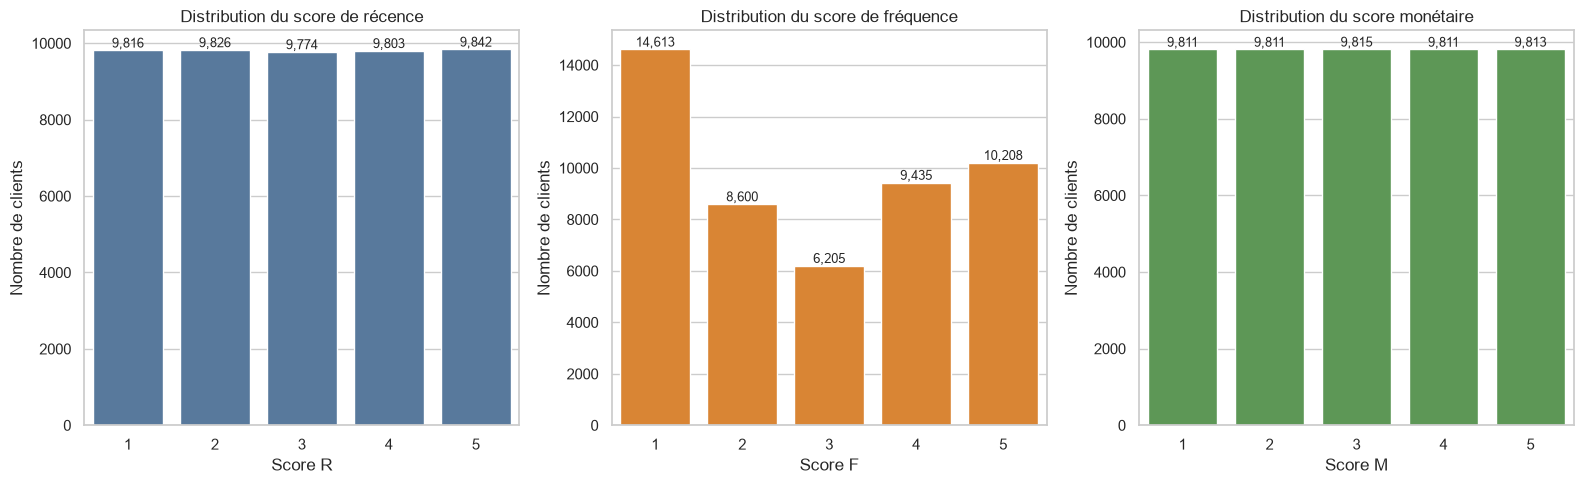

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

scores = ["R", "F", "M"]
titres = [
    "Distribution du score de récence",
    "Distribution du score de fréquence",
    "Distribution du score monétaire"
]
couleurs = ["#4C78A8", "#F58518", "#54A24B"]

for axe, score, titre, couleur in zip(axes, scores, titres, couleurs):
    distribution = (
        rfm[score]
        .value_counts()
        .sort_index()
    )

    sns.barplot(
        x=distribution.index,
        y=distribution.values,
        ax=axe,
        color=couleur
    )

    axe.set_title(titre)
    axe.set_xlabel(f"Score {score}")
    axe.set_ylabel("Nombre de clients")

    for index, valeur in enumerate(distribution.values):
        axe.text(
            index,
            valeur,
            f"{valeur:,}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

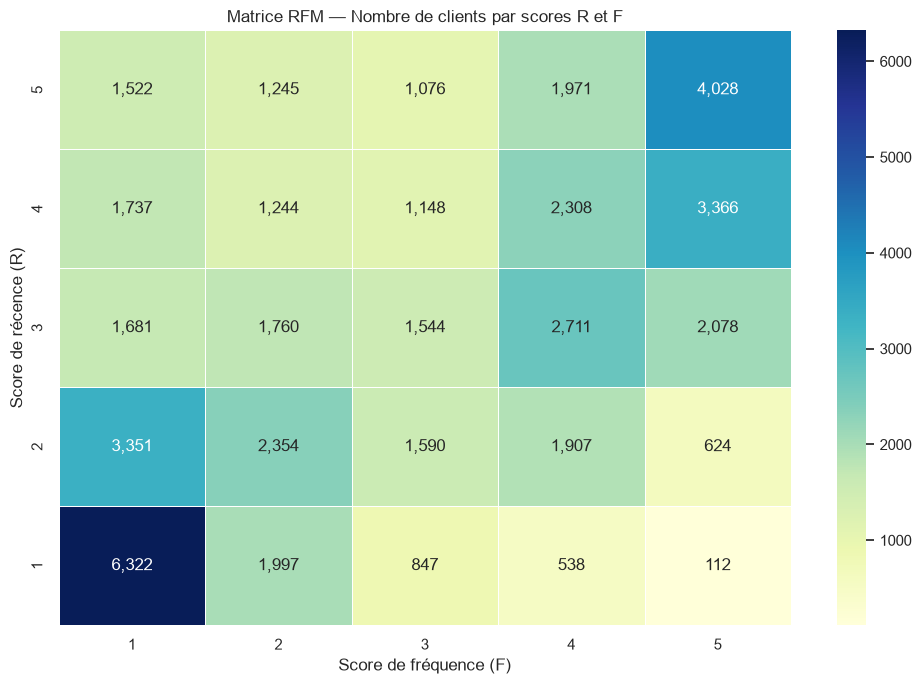

In [16]:
matrice_rfm = pd.crosstab(
    index=rfm["R"],
    columns=rfm["F"]
).sort_index(ascending=False)

plt.figure(figsize=(10, 7))

sns.heatmap(
    matrice_rfm,
    annot=True,
    fmt=",",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Matrice RFM — Nombre de clients par scores R et F")
plt.xlabel("Score de fréquence (F)")
plt.ylabel("Score de récence (R)")
plt.tight_layout()
plt.show()

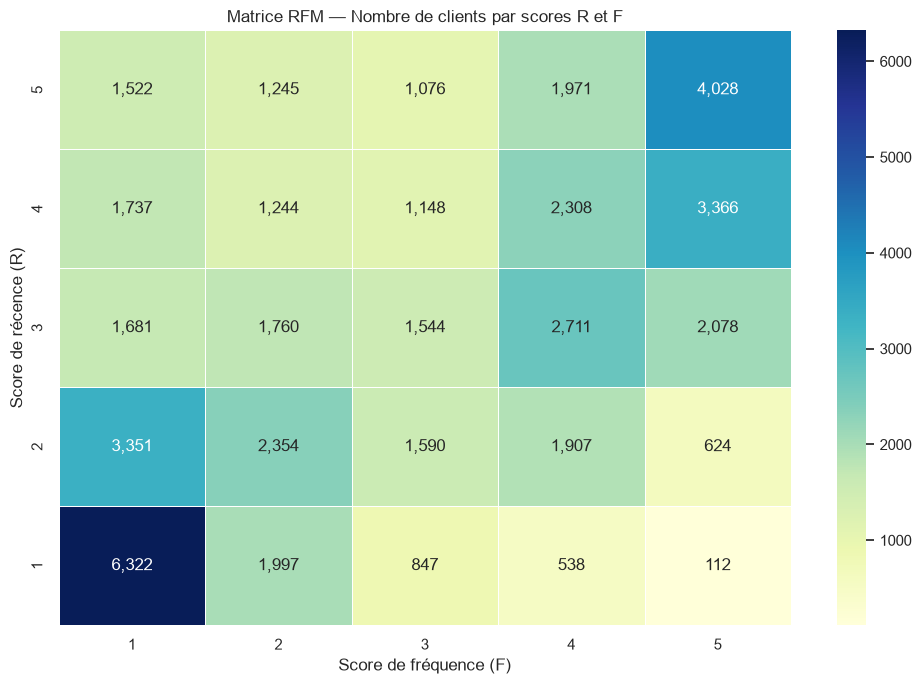

In [17]:
matrice_rfm = pd.crosstab(
    index=rfm["R"],
    columns=rfm["F"]
).sort_index(ascending=False)

plt.figure(figsize=(10, 7))

sns.heatmap(
    matrice_rfm,
    annot=True,
    fmt=",",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Matrice RFM — Nombre de clients par scores R et F")
plt.xlabel("Score de fréquence (F)")
plt.ylabel("Score de récence (R)")
plt.tight_layout()
plt.show()

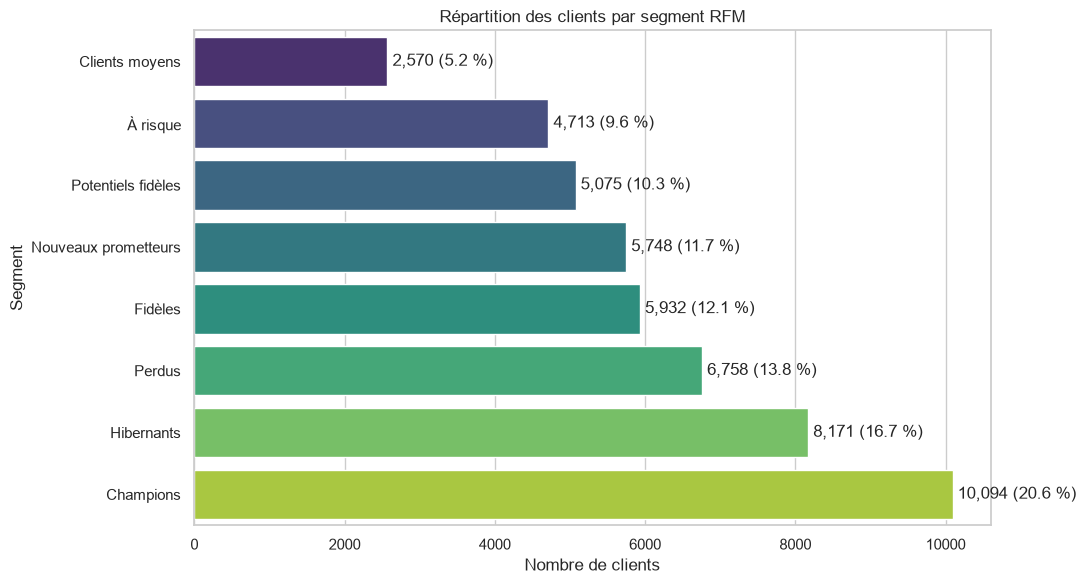

In [18]:
ordre_segments = (
    rfm["segment"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(11, 6))

axe = sns.barplot(
    x=ordre_segments.values,
    y=ordre_segments.index,
    hue=ordre_segments.index,
    palette="viridis",
    legend=False
)

plt.title("Répartition des clients par segment RFM")
plt.xlabel("Nombre de clients")
plt.ylabel("Segment")

for index, valeur in enumerate(ordre_segments.values):
    pourcentage = valeur / len(rfm) * 100
    axe.text(
        valeur,
        index,
        f" {valeur:,} ({pourcentage:.1f} %)",
        va="center"
    )

plt.tight_layout()
plt.show()

In [19]:
profil_segments = (
    rfm
    .groupby("segment")
    .agg(
        nombre_clients=("customer_id", "nunique"),
        recence_moyenne=("recence", "mean"),
        frequence_moyenne=("frequence", "mean"),
        montant_moyen=("montant", "mean"),
        panier_moyen=("panier_moyen", "mean"),
        anciennete_moyenne=("anciennete", "mean"),
        chiffre_affaires=("montant", "sum")
    )
    .reset_index()
)

profil_segments["part_clients_pct"] = (
    profil_segments["nombre_clients"] / len(rfm) * 100
)

profil_segments["part_ca_pct"] = (
    profil_segments["chiffre_affaires"] / rfm["montant"].sum() * 100
)

profil_segments = profil_segments.sort_values(
    "chiffre_affaires",
    ascending=False
)

colonnes_numeriques = profil_segments.select_dtypes(include="number").columns
profil_segments[colonnes_numeriques] = (
    profil_segments[colonnes_numeriques].round(2)
)

display(profil_segments)

,segment,nombre_clients,recence_moyenne,frequence_moyenne,montant_moyen,panier_moyen,anciennete_moyenne,chiffre_affaires,part_clients_pct,part_ca_pct
0,Champions,10094,58.17,10.31,"2,492.14",214.55,526.65,"25,155,674.30",20.57,64.29
2,Fidèles,5932,173.51,6.54,703.23,105.19,571.57,"4,171,533.51",12.09,10.66
7,À risque,4713,487.01,4.86,676.25,137.86,831.94,"3,187,152.91",9.61,8.15
6,Potentiels fidèles,5075,151.98,2.72,448.20,163.86,340.49,"2,274,636.82",10.34,5.81
3,Hibernants,8171,507.63,1.64,250.79,181.93,604.82,"2,049,245.88",16.65,5.24
4,Nouveaux prometteurs,5748,61.94,1.43,253.91,173.33,104.79,"1,459,494.15",11.72,3.73
5,Perdus,6758,831.77,1.18,72.93,63.45,861.26,"492,836.70",13.77,1.26
1,Clients moyens,2570,202.42,1.79,130.74,108.24,280.34,"336,000.50",5.24,0.86


In [20]:
customers = pd.read_csv(
    "customers.csv",
    parse_dates=["first_purchase", "last_purchase"]
)

colonnes_clients = [
    "customer_id",
    "country",
    "declared_preference",
    "age_bracket",
    "life_stage",
    "urban_density"
]

customers_unique = (
    customers[colonnes_clients]
    .drop_duplicates(subset=["customer_id"])
)

rfm_enrichi = rfm.merge(
    customers_unique,
    on="customer_id",
    how="left",
    validate="one_to_one"
)

print(f"Nombre de lignes après fusion : {len(rfm_enrichi):,}")
print("\nValeurs démographiques disponibles :")

display(
    rfm_enrichi[
        [
            "country",
            "declared_preference",
            "age_bracket",
            "life_stage",
            "urban_density"
        ]
    ]
    .notna()
    .sum()
    .to_frame("valeurs_disponibles")
)

Nombre de lignes après fusion : 49,061

Valeurs démographiques disponibles :


,valeurs_disponibles
country,49050
declared_preference,18650
age_bracket,20921
life_stage,11020
urban_density,9729


In [21]:
pays_par_segment = (
    rfm_enrichi
    .dropna(subset=["country"])
    .groupby(["segment", "country"])
    .size()
    .reset_index(name="nombre")
)

pays_dominant = (
    pays_par_segment
    .sort_values(["segment", "nombre"], ascending=[True, False])
    .drop_duplicates(subset=["segment"])
    .rename(columns={
        "country": "pays_principal",
        "nombre": "clients_pays_principal"
    })
)

profil_demographique = (
    rfm_enrichi
    .groupby("segment")
    .agg(
        nombre_clients=("customer_id", "nunique"),
        anciennete_moyenne_jours=("anciennete", "mean"),
        anciennete_mediane_jours=("anciennete", "median")
    )
    .reset_index()
    .merge(
        pays_dominant[
            ["segment", "pays_principal", "clients_pays_principal"]
        ],
        on="segment",
        how="left"
    )
)

profil_demographique["part_pays_principal_pct"] = (
    profil_demographique["clients_pays_principal"]
    / profil_demographique["nombre_clients"]
    * 100
)

profil_demographique[
    [
        "anciennete_moyenne_jours",
        "anciennete_mediane_jours",
        "part_pays_principal_pct"
    ]
] = profil_demographique[
    [
        "anciennete_moyenne_jours",
        "anciennete_mediane_jours",
        "part_pays_principal_pct"
    ]
].round(2)

display(
    profil_demographique.sort_values(
        "anciennete_moyenne_jours",
        ascending=False
    )
)

,segment,nombre_clients,anciennete_moyenne_jours,anciennete_mediane_jours,pays_principal,clients_pays_principal,part_pays_principal_pct
5,Perdus,6758,861.26,818.00,France,6253,92.53
7,À risque,4713,831.94,821.00,France,4423,93.85
3,Hibernants,8171,604.82,545.00,France,7481,91.56
2,Fidèles,5932,571.57,602.00,France,5395,90.95
0,Champions,10094,526.65,570.00,France,9209,91.23
6,Potentiels fidèles,5075,340.49,324.00,France,4602,90.68
1,Clients moyens,2570,280.34,250.00,France,2321,90.31
4,Nouveaux prometteurs,5748,104.79,75.00,France,5090,88.55


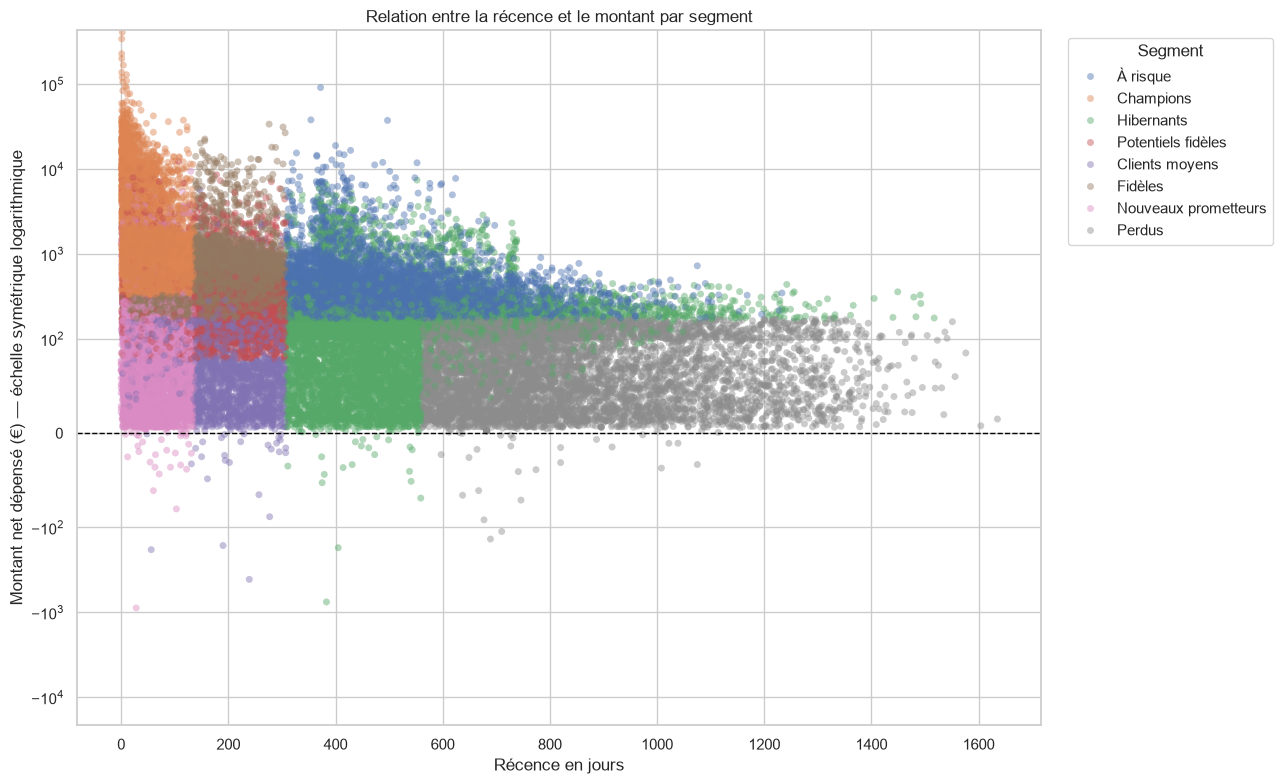

In [22]:
plt.figure(figsize=(13, 8))

sns.scatterplot(
    data=rfm,
    x="recence",
    y="montant",
    hue="segment",
    alpha=0.45,
    s=25,
    linewidth=0
)

# Échelle adaptée aux montants très élevés et aux montants négatifs
plt.yscale("symlog", linthresh=100)

plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title("Relation entre la récence et le montant par segment")
plt.xlabel("Récence en jours")
plt.ylabel("Montant net dépensé (€) — échelle symétrique logarithmique")
plt.legend(
    title="Segment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## Interprétation de la relation entre récence et valeur

Le scatter plot confirme que la récence et la valeur client entretiennent une relation complexe et non strictement linéaire.

Les **Champions** sont principalement concentrés parmi les clients récents et présentent les montants les plus élevés. Les **Nouveaux prometteurs** sont également récents, mais leur montant reste souvent plus faible parce qu’ils ont encore réalisé peu de commandes.

Les clients **À risque** se situent à une récence plus élevée tout en conservant une valeur historique importante. Ils constituent donc une cible prioritaire pour les campagnes de réactivation. Les clients **Perdus** sont les plus anciens et possèdent généralement une faible valeur, ce qui limite l’intérêt de campagnes coûteuses.

Le graphique montre également que deux clients ayant une récence similaire peuvent présenter des valeurs très différentes. La récence ne doit donc pas être utilisée seule : elle doit être combinée avec la fréquence et le montant.

In [23]:
recommandations = pd.DataFrame([
    {
        "priorite": 1,
        "segment": "À risque",
        "profil": "Clients historiquement rentables devenus inactifs",
        "potentiel": "Valeur élevée à récupérer",
        "risque": "Churn imminent",
        "action": "Email personnalisé avec offre de retour limitée et recommandations basées sur les anciens achats",
        "critere_priorite": "Risque de perdre des clients à forte valeur",
        "budget_traitement": "Élevé",
        "metrique_succes": "Taux de réactivation sous 30 jours"
    },
    {
        "priorite": 2,
        "segment": "Champions",
        "profil": "Clients récents, fréquents et à forte valeur",
        "potentiel": "Très forte valeur actuelle et future",
        "risque": "Déception ou départ vers un concurrent",
        "action": "Programme VIP, accès anticipé, recommandations personnalisées et avantages exclusifs",
        "critere_priorite": "Protection de 64,29 % du chiffre d’affaires",
        "budget_traitement": "Très élevé",
        "metrique_succes": "Taux de rétention et fréquence d’achat"
    },
    {
        "priorite": 3,
        "segment": "Potentiels fidèles",
        "profil": "Clients récents avec plusieurs achats",
        "potentiel": "Peuvent devenir Fidèles ou Champions",
        "risque": "Relation encore insuffisamment installée",
        "action": "Programme de fidélité, offre sur la prochaine commande et recommandations complémentaires",
        "critere_priorite": "Fort potentiel de croissance",
        "budget_traitement": "Élevé",
        "metrique_succes": "Passage à une commande supplémentaire"
    },
    {
        "priorite": 4,
        "segment": "Nouveaux prometteurs",
        "profil": "Nouveaux clients ayant encore peu commandé",
        "potentiel": "Première relation commerciale encourageante",
        "risque": "Absence de deuxième commande",
        "action": "Parcours de bienvenue, présentation de la marque et avantage sur le deuxième achat",
        "critere_priorite": "Transformer le premier achat en relation durable",
        "budget_traitement": "Moyen à élevé",
        "metrique_succes": "Taux de deuxième commande sous 60 jours"
    },
    {
        "priorite": 5,
        "segment": "Fidèles",
        "profil": "Clients réguliers et rentables",
        "potentiel": "Peuvent évoluer vers le segment Champions",
        "risque": "Baisse progressive de l’engagement",
        "action": "Récompenses de fidélité, ventes croisées et recommandations personnalisées",
        "critere_priorite": "Valeur actuelle stable",
        "budget_traitement": "Moyen",
        "metrique_succes": "Progression du panier et de la fréquence"
    },
    {
        "priorite": 6,
        "segment": "Hibernants",
        "profil": "Clients anciens avec une activité limitée",
        "potentiel": "Réactivation possible pour une partie du segment",
        "risque": "Passage vers le segment Perdus",
        "action": "Campagne automatisée peu coûteuse avec test de plusieurs offres",
        "critere_priorite": "Risque modéré avec valeur limitée",
        "budget_traitement": "Faible à moyen",
        "metrique_succes": "Taux de clic et taux de réactivation"
    },
    {
        "priorite": 7,
        "segment": "Clients moyens",
        "profil": "Clients au comportement intermédiaire",
        "potentiel": "Progression possible avec davantage d’engagement",
        "risque": "Stagnation ou baisse de fréquence",
        "action": "Newsletter personnalisée et recommandations selon les catégories achetées",
        "critere_priorite": "Potentiel présent mais moins clairement identifié",
        "budget_traitement": "Faible",
        "metrique_succes": "Évolution de la fréquence d’achat"
    },
    {
        "priorite": 8,
        "segment": "Perdus",
        "profil": "Clients très anciens, peu fréquents et à faible valeur",
        "potentiel": "Faible",
        "risque": "Clients probablement définitivement perdus",
        "action": "Un unique email de reconquête puis exclusion des campagnes coûteuses en cas d’absence de réponse",
        "critere_priorite": "Faible retour sur investissement attendu",
        "budget_traitement": "Très faible",
        "metrique_succes": "Réactivation après l’unique campagne"
    }
])

display(
    recommandations
    .sort_values("priorite")
    .style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal"
    })
)

priorite,segment,profil,potentiel,risque,action,critere_priorite,budget_traitement,metrique_succes
1,À risque,Clients historiquement rentables devenus inactifs,Valeur élevée à récupérer,Churn imminent,Email personnalisé avec offre de retour limitée et recommandations basées sur les anciens achats,Risque de perdre des clients à forte valeur,Élevé,Taux de réactivation sous 30 jours
2,Champions,"Clients récents, fréquents et à forte valeur",Très forte valeur actuelle et future,Déception ou départ vers un concurrent,"Programme VIP, accès anticipé, recommandations personnalisées et avantages exclusifs","Protection de 64,29 % du chiffre d’affaires",Très élevé,Taux de rétention et fréquence d’achat
3,Potentiels fidèles,Clients récents avec plusieurs achats,Peuvent devenir Fidèles ou Champions,Relation encore insuffisamment installée,"Programme de fidélité, offre sur la prochaine commande et recommandations complémentaires",Fort potentiel de croissance,Élevé,Passage à une commande supplémentaire
4,Nouveaux prometteurs,Nouveaux clients ayant encore peu commandé,Première relation commerciale encourageante,Absence de deuxième commande,"Parcours de bienvenue, présentation de la marque et avantage sur le deuxième achat",Transformer le premier achat en relation durable,Moyen à élevé,Taux de deuxième commande sous 60 jours
5,Fidèles,Clients réguliers et rentables,Peuvent évoluer vers le segment Champions,Baisse progressive de l’engagement,"Récompenses de fidélité, ventes croisées et recommandations personnalisées",Valeur actuelle stable,Moyen,Progression du panier et de la fréquence
6,Hibernants,Clients anciens avec une activité limitée,Réactivation possible pour une partie du segment,Passage vers le segment Perdus,Campagne automatisée peu coûteuse avec test de plusieurs offres,Risque modéré avec valeur limitée,Faible à moyen,Taux de clic et taux de réactivation
7,Clients moyens,Clients au comportement intermédiaire,Progression possible avec davantage d’engagement,Stagnation ou baisse de fréquence,Newsletter personnalisée et recommandations selon les catégories achetées,Potentiel présent mais moins clairement identifié,Faible,Évolution de la fréquence d’achat
8,Perdus,"Clients très anciens, peu fréquents et à faible valeur",Faible,Clients probablement définitivement perdus,Un unique email de reconquête puis exclusion des campagnes coûteuses en cas d’absence de réponse,Faible retour sur investissement attendu,Très faible,Réactivation après l’unique campagne


Réponses disponibles : 2,155 sur 5,748 Nouveaux prometteurs


,nombre_clients,proportion_pct
declared_preference,,
Anti-âge,341,15.82
Recherche vegan,322,14.94
Peau mixte,315,14.62
Peau sensible,313,14.52
Anti-imperfections,290,13.46
Sans parfum,289,13.41
Peau sèche,285,13.23


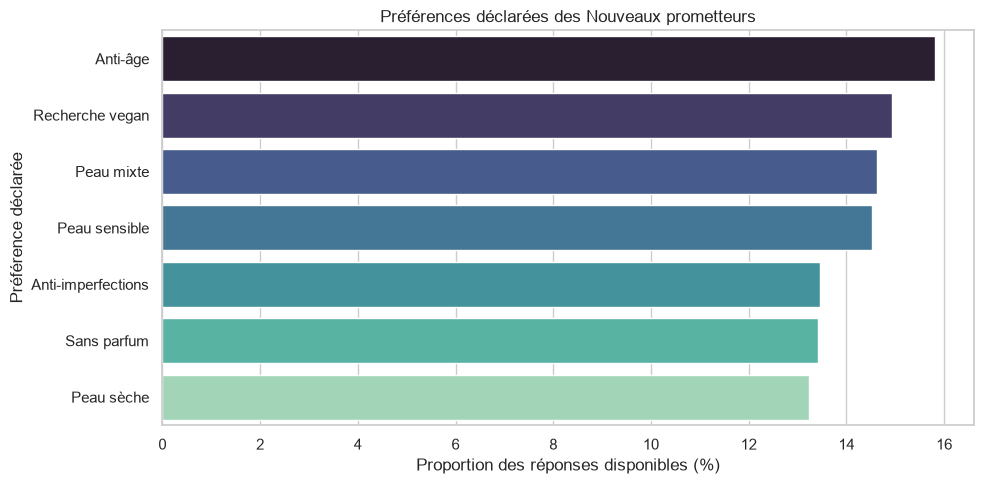

In [24]:
nouveaux_preferences = (
    rfm_enrichi.loc[
        rfm_enrichi["segment"] == "Nouveaux prometteurs",
        "declared_preference"
    ]
    .dropna()
    .value_counts()
)

nouveaux_preferences_pct = (
    nouveaux_preferences
    / nouveaux_preferences.sum()
    * 100
).round(2)

analyse_preferences = pd.DataFrame({
    "nombre_clients": nouveaux_preferences,
    "proportion_pct": nouveaux_preferences_pct
})

print(
    f"Réponses disponibles : "
    f"{nouveaux_preferences.sum():,} sur "
    f"{(rfm_enrichi['segment'] == 'Nouveaux prometteurs').sum():,} "
    f"Nouveaux prometteurs"
)

display(analyse_preferences)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=nouveaux_preferences_pct.values,
    y=nouveaux_preferences_pct.index,
    hue=nouveaux_preferences_pct.index,
    palette="mako",
    legend=False
)

plt.title("Préférences déclarées des Nouveaux prometteurs")
plt.xlabel("Proportion des réponses disponibles (%)")
plt.ylabel("Préférence déclarée")
plt.tight_layout()
plt.show()

## Enrichissement du segment avec les préférences déclarées

Le croisement entre le segment **Nouveaux prometteurs** et la variable `declared_preference` apporte une information plus précise que le RFM seul.

Le RFM indique que ces clients sont récents et ont encore peu commandé, mais il ne précise pas leurs besoins. La préférence **Anti-âge** est la plus représentée parmi les réponses disponibles, suivie notamment par la recherche de produits vegan, les peaux mixtes et les peaux sensibles. Toutefois, aucune préférence ne domine très largement : le segment reste hétérogène.

Au lieu d’envoyer un message générique identique à tous les Nouveaux prometteurs, Lumina & Co pourrait donc personnaliser le contenu selon la préférence déclarée :

- proposer une routine anti-âge aux clients concernés ;
- mettre en avant les ingrédients et certifications pour les clients recherchant des produits vegan ;
- recommander une routine adaptée aux peaux sensibles, mixtes ou sèches ;
- envoyer ces recommandations par email personnalisé après la première commande.

Cette personnalisation pourrait augmenter le taux de deuxième commande. L’analyse doit néanmoins rester prudente, car les préférences ne sont disponibles que pour une partie des clients du segment.

In [25]:
rfm_enrichi.to_csv(
    "rfm_segments.csv",
    index=False,
    encoding="utf-8-sig"
)

profil_segments.to_csv(
    "profil_segments.csv",
    index=False,
    encoding="utf-8-sig"
)

recommandations.to_csv(
    "carte_segments_marketing.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Exports terminés avec succès :")
print("- rfm_segments.csv")
print("- profil_segments.csv")
print("- carte_segments_marketing.csv")

Exports terminés avec succès :
- rfm_segments.csv
- profil_segments.csv
- carte_segments_marketing.csv
